# Target and Historical Window Ablation

Previous notebooks used a rolling window and EMA span of five cycles as
initial baseline choices.

This notebook evaluates whether those values are empirically justified.

The experiment keeps the following components fixed:

- selected sensors,
- target definition,
- Random Forest model,
- engine-level train-validation split,
- model hyperparameters,
- and evaluation metrics.

Only the historical window and EMA span are changed.

This controlled design helps isolate the effect of the temporal context
length on RUL prediction performance.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GroupShuffleSplit

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_cmapss_data
from src.preprocessing import add_sensor_history_features
from src.rul_builder import add_train_rul

## Load the FD001 Training Data

The same FD001 training dataset and linear RUL definition used in the
previous modeling notebooks are reproduced here.

The official NASA test set remains untouched during this experiment.

All design decisions are evaluated only on the held-out validation
engines.

In [2]:
train_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "train_FD001.txt"
)

base_df = load_cmapss_data(train_path)
base_df = add_train_rul(base_df)

base_df.head()

,id,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [3]:
assert len(base_df) == 20631
assert base_df["id"].nunique() == 100
assert "RUL" in base_df.columns
assert "max_cycle" not in base_df.columns
assert (base_df.groupby("id").tail(1)["RUL"] == 0).all()

print("Base training dataset prepared successfully.")

Base training dataset prepared successfully.


## Fixed Candidate Sensor Set

The same candidate sensors selected in Notebook 03 and used in
Notebooks 04 and 05 are retained.

Changing the sensor set during the window experiment would make it
impossible to isolate the effect of temporal window length.

In [4]:
selected_sensors = [
    "s2",
    "s3",
    "s4",
    "s7",
    "s11",
    "s12",
    "s15",
    "s17",
    "s20",
    "s21",
]

assert all(
    sensor in base_df.columns
    for sensor in selected_sensors
)

print("Selected sensors:", selected_sensors)

Selected sensors: ['s2', 's3', 's4', 's7', 's11', 's12', 's15', 's17', 's20', 's21']


## Fixed Engine-Level Split

The engine-level split is created once and reused for every window
candidate.

This ensures that each configuration is evaluated on exactly the same
training and validation engines.

If a new random split were generated for every experiment, performance
differences could be caused by different engine populations rather than
by the window size itself.

In [5]:
engine_table = pd.DataFrame(
    {
        "id": sorted(base_df["id"].unique())
    }
)

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_engine_indices, validation_engine_indices = next(
    group_splitter.split(
        engine_table,
        groups=engine_table["id"],
    )
)

train_engine_ids = set(
    engine_table.iloc[train_engine_indices]["id"]
)

validation_engine_ids = set(
    engine_table.iloc[validation_engine_indices]["id"]
)

print("Training engines:", len(train_engine_ids))
print("Validation engines:", len(validation_engine_ids))
print(
    "Shared engines:",
    len(train_engine_ids & validation_engine_ids),
)

Training engines: 80
Validation engines: 20
Shared engines: 0


In [6]:
assert len(train_engine_ids) == 80
assert len(validation_engine_ids) == 20
assert train_engine_ids.isdisjoint(validation_engine_ids)

assert (
    train_engine_ids | validation_engine_ids
    == set(base_df["id"].unique())
)

print("Fixed engine-level split validated.")

Fixed engine-level split validated.


## Temporal Window Candidates

The following short-, medium-, and longer-term contexts are evaluated:

- 3 cycles
- 5 cycles
- 10 cycles
- 20 cycles

For each candidate value, the same number is used for:

- the rolling-mean window,
- and the EMA span.

This keeps the initial ablation compact and interpretable.

A later experiment could tune rolling windows and EMA spans separately,
but that added search space is not necessary at the current stage.

In [7]:
window_candidates = [3, 5, 10, 20]

window_candidates

[3, 5, 10, 20]

In [8]:
def build_feature_columns(
    sensors,
    rolling_window,
    ema_span,
):
    historical_features = [
        f"{sensor}_{suffix}"
        for sensor in sensors
        for suffix in [
            "diff_1",
            f"rolling_mean_{rolling_window}",
            f"ema_{ema_span}",
            "expanding_mean",
        ]
    ]

    return (
        ["cycle"]
        + list(sensors)
        + historical_features
    )

## Fixed Reference Model

Random Forest is used because it achieved the strongest validation
performance in the previous experiments.

Its hyperparameters remain fixed throughout the ablation.

The objective is not to tune the model and the window simultaneously.
Only the temporal feature configuration is allowed to change.

In [9]:
window_results = []

for window in window_candidates:
    experiment_start = time.perf_counter()

    experiment_df = add_sensor_history_features(
        base_df,
        sensors=selected_sensors,
        rolling_window=window,
        ema_span=window,
    ).reset_index(drop=True)

    feature_columns = build_feature_columns(
        sensors=selected_sensors,
        rolling_window=window,
        ema_span=window,
    )

    train_df = experiment_df[
        experiment_df["id"].isin(train_engine_ids)
    ].reset_index(drop=True)

    validation_df = experiment_df[
        experiment_df["id"].isin(validation_engine_ids)
    ].reset_index(drop=True)

    X_train = train_df[feature_columns]
    y_train = train_df["RUL"]

    X_validation = validation_df[feature_columns]
    y_validation = validation_df["RUL"]

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(
        X_train,
        y_train,
    )

    predictions = model.predict(
        X_validation
    )

    mae = mean_absolute_error(
        y_validation,
        predictions,
    )

    rmse = root_mean_squared_error(
        y_validation,
        predictions,
    )

    r2 = r2_score(
        y_validation,
        predictions,
    )

    elapsed_seconds = (
        time.perf_counter()
        - experiment_start
    )

    window_results.append(
        {
            "window": window,
            "ema_span": window,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "elapsed_seconds": elapsed_seconds,
            "negative_predictions": int(
                (predictions < 0).sum()
            ),
        }
    )

    print(
        f"Window {window}: "
        f"MAE={mae:.3f}, "
        f"RMSE={rmse:.3f}, "
        f"R²={r2:.3f}, "
        f"time={elapsed_seconds:.1f}s"
    )

Window 3: MAE=20.988, RMSE=27.808, R²=0.821, time=3.1s
Window 5: MAE=20.502, RMSE=27.197, R²=0.828, time=3.2s
Window 10: MAE=20.146, RMSE=26.702, R²=0.835, time=3.3s
Window 20: MAE=20.286, RMSE=26.914, R²=0.832, time=3.8s


In [10]:
window_results_df = pd.DataFrame(
    window_results
).sort_values(
    "MAE"
).reset_index(drop=True)

window_results_df

,window,ema_span,MAE,RMSE,R2,elapsed_seconds,negative_predictions
0,10,10,20.145522,26.702136,0.834576,3.329246,0
1,20,20,20.285639,26.913944,0.831942,3.821990,0
2,5,5,20.501993,27.196593,0.828393,3.217746,0
3,3,3,20.988183,27.808017,0.820591,3.109189,0


In [11]:
assert len(window_results_df) == len(
    window_candidates
)

assert set(
    window_results_df["window"]
) == set(window_candidates)

assert window_results_df[
    ["MAE", "RMSE", "R2"]
].isna().sum().sum() == 0

assert np.isfinite(
    window_results_df[
        ["MAE", "RMSE", "R2"]
    ].to_numpy()
).all()

print("Window ablation results validated.")

Window ablation results validated.


In [12]:
best_window_row = window_results_df.iloc[0]

best_window = int(
    best_window_row["window"]
)

print("Best window by MAE:", best_window)
print(
    "Best validation MAE:",
    f"{best_window_row['MAE']:.3f}",
)
print(
    "Best validation RMSE:",
    f"{best_window_row['RMSE']:.3f}",
)
print(
    "Best validation R²:",
    f"{best_window_row['R2']:.3f}",
)

Best window by MAE: 10
Best validation MAE: 20.146
Best validation RMSE: 26.702
Best validation R²: 0.835


In [13]:
baseline_window = 5

baseline_window_row = window_results_df.loc[
    window_results_df["window"] == baseline_window
].iloc[0]

mae_improvement_vs_baseline = (
    (
        baseline_window_row["MAE"]
        - best_window_row["MAE"]
    )
    / baseline_window_row["MAE"]
    * 100
)

rmse_improvement_vs_baseline = (
    (
        baseline_window_row["RMSE"]
        - best_window_row["RMSE"]
    )
    / baseline_window_row["RMSE"]
    * 100
)

print(
    f"MAE improvement over window {baseline_window}: "
    f"{mae_improvement_vs_baseline:.2f}%"
)

print(
    f"RMSE improvement over window {baseline_window}: "
    f"{rmse_improvement_vs_baseline:.2f}%"
)

MAE improvement over window 5: 1.74%
RMSE improvement over window 5: 1.82%


In [14]:
assert best_window == 10, (
    "Unexpected best window for the current controlled experiment."
)

assert best_window_row["MAE"] < baseline_window_row["MAE"]

assert best_window_row["RMSE"] < baseline_window_row["RMSE"]

assert best_window_row["R2"] > baseline_window_row["R2"]

print("Window-selection validation passed.")

Window-selection validation passed.


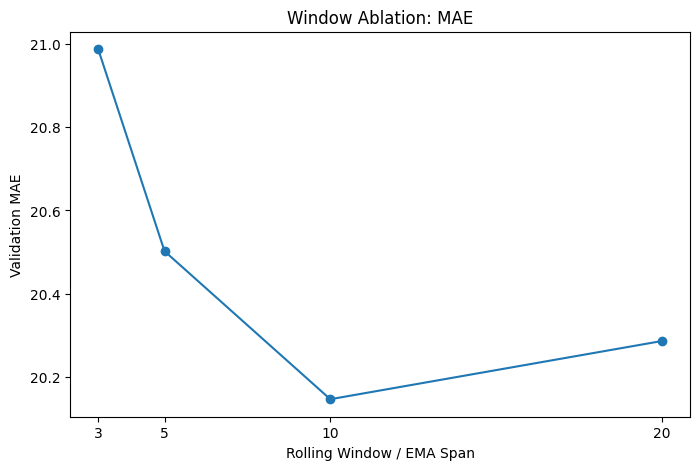

In [15]:
plot_data = (
    window_results_df
    .sort_values("window")
)

plt.figure(figsize=(8, 5))

plt.plot(
    plot_data["window"],
    plot_data["MAE"],
    marker="o",
)

plt.xlabel("Rolling Window / EMA Span")
plt.ylabel("Validation MAE")
plt.title("Window Ablation: MAE")
plt.xticks(window_candidates)
plt.show()

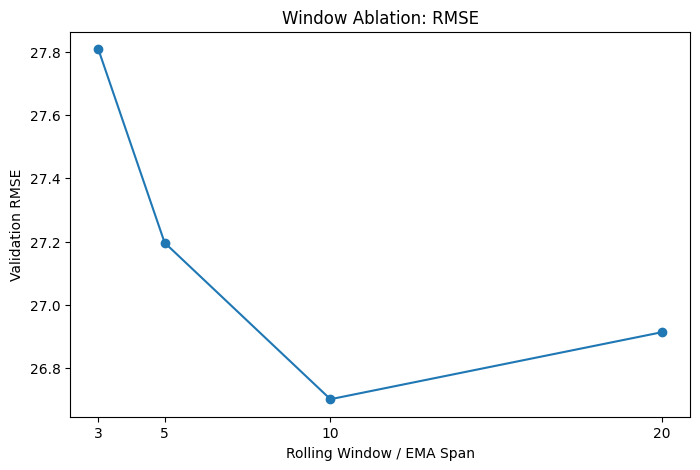

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    plot_data["window"],
    plot_data["RMSE"],
    marker="o",
)

plt.xlabel("Rolling Window / EMA Span")
plt.ylabel("Validation RMSE")
plt.title("Window Ablation: RMSE")
plt.xticks(window_candidates)
plt.show()

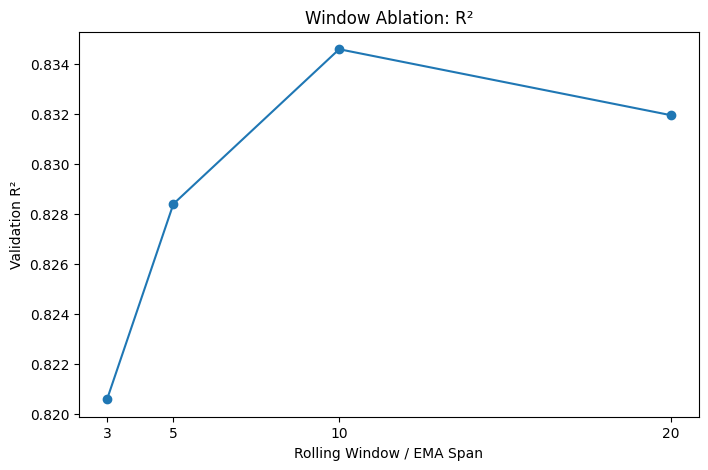

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    plot_data["window"],
    plot_data["R2"],
    marker="o",
)

plt.xlabel("Rolling Window / EMA Span")
plt.ylabel("Validation R²")
plt.title("Window Ablation: R²")
plt.xticks(window_candidates)
plt.show()

## Window Ablation Results

The controlled ablation evaluated rolling-window and EMA-span values of
3, 5, 10, and 20 cycles.

All other experimental components were kept fixed:

- the linear RUL target,
- the selected sensor set,
- the Random Forest architecture,
- model hyperparameters,
- the engine-level train-validation split,
- and the evaluation metrics.

The results were:

| Window / EMA Span | MAE | RMSE | R² |
|---:|---:|---:|---:|
| 3 | 20.988 | 27.808 | 0.821 |
| 5 | 20.502 | 27.197 | 0.828 |
| 10 | 20.146 | 26.702 | 0.835 |
| 20 | 20.286 | 26.914 | 0.832 |

A temporal context of 10 cycles achieved the best performance across
all three evaluation metrics.

Compared with the original five-cycle baseline, the 10-cycle
configuration improved:

- MAE by approximately 1.74%,
- RMSE by approximately 1.82%,
- and R² from 0.828 to 0.835.

The results suggest that three or five cycles provide insufficient
historical context for capturing the degradation trend as effectively
as a 10-cycle window.

Increasing the context to 20 cycles did not provide further
improvement. The longer window may smooth recent changes too strongly
or include older observations that are less representative of the
engine's current condition.

The improvement from five to 10 cycles is modest rather than dramatic.
However, MAE, RMSE, and R² all support the same choice, and the
computational cost remained nearly unchanged.

Therefore, a rolling window and EMA span of 10 cycles are selected as
the preferred configuration for the current feature set and validation
split.

### Limitations of the Window Experiment

This experiment does not prove that 10 cycles is universally optimal.

The result is conditional on:

- the FD001 dataset,
- the selected sensors,
- the current historical feature definitions,
- the Random Forest model,
- the current engine-level validation split,
- and the linear RUL target.

The rolling window and EMA span were also varied together. Their
individual effects were not separated.

A broader search or repeated group-based validation could provide a
more stable estimate, but that additional complexity is deferred
because the current experiment already provides an empirical
justification for replacing the arbitrary five-cycle baseline.

In [18]:
window_selection_summary = {
    "evaluated_windows": window_candidates,
    "selected_window": best_window,
    "selected_ema_span": best_window,
    "validation_mae": float(best_window_row["MAE"]),
    "validation_rmse": float(best_window_row["RMSE"]),
    "validation_r2": float(best_window_row["R2"]),
    "mae_improvement_vs_window_5_percent": float(
        mae_improvement_vs_baseline
    ),
    "rmse_improvement_vs_window_5_percent": float(
        rmse_improvement_vs_baseline
    ),
}

window_selection_summary

{'evaluated_windows': [3, 5, 10, 20],
 'selected_window': 10,
 'selected_ema_span': 10,
 'validation_mae': 20.14552212056303,
 'validation_rmse': 26.702136101036263,
 'validation_r2': 0.8345764501140267,
 'mae_improvement_vs_window_5_percent': 1.7387109899434012,
 'rmse_improvement_vs_window_5_percent': 1.818083663352291}

# Linear RUL vs Capped RUL

The previous notebooks used a linear RUL target:

$$
RUL_{linear,i,t} = T_i - t
$$

This formulation assumes that every cycle of remaining life should be
distinguished equally, including the early healthy phase of an engine.

However, sensor behavior during the early operating period may not
contain enough information to distinguish very large RUL values
reliably.

A capped or piecewise-linear target is therefore also evaluated:

$$
RUL_{capped,i,t}
=
\min\left(
RUL_{linear,i,t},
RUL_{max}
\right)
$$

The current experiment uses:

$$
RUL_{max} = 125
$$

This value is treated as an experimental modeling assumption rather
than a universal physical constant.

The objective is to determine whether capping the early healthy region
improves prediction quality without drawing misleading conclusions from
easier target values.

In [19]:
RUL_CAP = 125

print("Capped RUL threshold:", RUL_CAP)

Capped RUL threshold: 125


In [20]:
target_experiment_df = add_sensor_history_features(
    base_df,
    sensors=selected_sensors,
    rolling_window=best_window,
    ema_span=best_window,
).reset_index(drop=True)

target_experiment_df["RUL_linear"] = (
    target_experiment_df["RUL"]
)

target_experiment_df["RUL_capped"] = (
    target_experiment_df["RUL_linear"]
    .clip(upper=RUL_CAP)
)

target_experiment_df[
    [
        "id",
        "cycle",
        "RUL_linear",
        "RUL_capped",
    ]
].head()

,id,cycle,RUL_linear,RUL_capped
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125


In [21]:
assert (
    target_experiment_df["RUL_capped"]
    <= RUL_CAP
).all()

assert (
    target_experiment_df["RUL_capped"]
    <= target_experiment_df["RUL_linear"]
).all()

assert (
    target_experiment_df.loc[
        target_experiment_df["RUL_linear"] <= RUL_CAP,
        "RUL_linear",
    ].to_numpy()
    ==
    target_experiment_df.loc[
        target_experiment_df["RUL_linear"] <= RUL_CAP,
        "RUL_capped",
    ].to_numpy()
).all()

assert (
    target_experiment_df.groupby("id").tail(1)[
        ["RUL_linear", "RUL_capped"]
    ] == 0
).all().all()

print("Linear and capped RUL targets validated.")

Linear and capped RUL targets validated.


## Target Distribution Comparison

The capped target changes only the early healthy region.

For cycles where linear RUL is less than or equal to 125, the two target
definitions are identical.

For larger values, capped RUL assigns the same value of 125.

This reduces the requirement for the model to distinguish between
high-RUL observations that may have very similar sensor behavior.

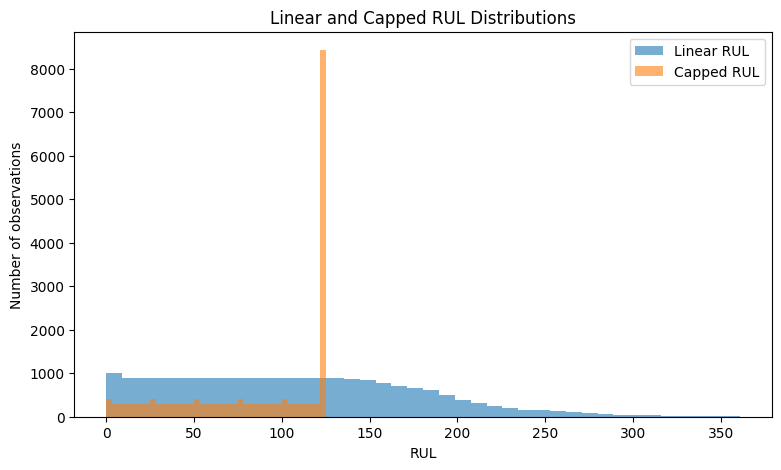

In [22]:
plt.figure(figsize=(9, 5))

plt.hist(
    target_experiment_df["RUL_linear"],
    bins=40,
    alpha=0.6,
    label="Linear RUL",
)

plt.hist(
    target_experiment_df["RUL_capped"],
    bins=40,
    alpha=0.6,
    label="Capped RUL",
)

plt.xlabel("RUL")
plt.ylabel("Number of observations")
plt.title("Linear and Capped RUL Distributions")
plt.legend()
plt.show()

In [23]:
capped_rows = (
    target_experiment_df["RUL_linear"]
    > RUL_CAP
).sum()

capped_percentage = (
    capped_rows
    / len(target_experiment_df)
    * 100
)

print("Rows affected by capping:", capped_rows)
print(
    f"Percentage affected by capping: "
    f"{capped_percentage:.2f}%"
)

Rows affected by capping: 8031
Percentage affected by capping: 38.93%


In [24]:
target_train_df = target_experiment_df[
    target_experiment_df["id"].isin(
        train_engine_ids
    )
].reset_index(drop=True)

target_validation_df = target_experiment_df[
    target_experiment_df["id"].isin(
        validation_engine_ids
    )
].reset_index(drop=True)

In [25]:
target_feature_columns = build_feature_columns(
    sensors=selected_sensors,
    rolling_window=best_window,
    ema_span=best_window,
)

X_target_train = target_train_df[
    target_feature_columns
]

X_target_validation = target_validation_df[
    target_feature_columns
]

## Experiment A — Linear RUL Model

The first Random Forest is trained using the original linear RUL target.

This reproduces the previous modeling objective while using the
empirically selected 10-cycle historical configuration.

In [26]:
linear_rul_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

linear_rul_model.fit(
    X_target_train,
    target_train_df["RUL_linear"],
)

linear_predictions = linear_rul_model.predict(
    X_target_validation
)

In [27]:
linear_mae = mean_absolute_error(
    target_validation_df["RUL_linear"],
    linear_predictions,
)

linear_rmse = root_mean_squared_error(
    target_validation_df["RUL_linear"],
    linear_predictions,
)

linear_r2 = r2_score(
    target_validation_df["RUL_linear"],
    linear_predictions,
)

print(f"Linear target MAE:  {linear_mae:.3f}")
print(f"Linear target RMSE: {linear_rmse:.3f}")
print(f"Linear target R²:   {linear_r2:.3f}")

Linear target MAE:  20.146
Linear target RMSE: 26.702
Linear target R²:   0.835


## Experiment B — Capped RUL Model

The second Random Forest uses exactly the same:

- features,
- engine split,
- model architecture,
- hyperparameters,
- and random state.

Only the target definition changes from linear RUL to capped RUL.

This isolates the effect of target construction.

In [28]:
capped_rul_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

capped_rul_model.fit(
    X_target_train,
    target_train_df["RUL_capped"],
)

capped_predictions = capped_rul_model.predict(
    X_target_validation
)

In [29]:
capped_mae = mean_absolute_error(
    target_validation_df["RUL_capped"],
    capped_predictions,
)

capped_rmse = root_mean_squared_error(
    target_validation_df["RUL_capped"],
    capped_predictions,
)

capped_r2 = r2_score(
    target_validation_df["RUL_capped"],
    capped_predictions,
)

print(f"Capped target MAE:  {capped_mae:.3f}")
print(f"Capped target RMSE: {capped_rmse:.3f}")
print(f"Capped target R²:   {capped_r2:.3f}")

Capped target MAE:  8.415
Capped target RMSE: 11.575
Capped target R²:   0.923


### Important Comparison Limitation

The full-dataset MAE values for the linear and capped models are not
directly comparable as evidence of model superiority.

The capped target is easier because all RUL values above 125 are mapped
to a single value.

A lower capped-target MAE may therefore partly reflect a simplified
prediction task rather than a genuinely better estimate of the full
remaining lifetime.

For this reason, both models are also evaluated on the shared critical
region where:

$$
RUL \leq 125
$$

In this region, the linear and capped targets are identical.

In [30]:
critical_region_mask = (
    target_validation_df["RUL_linear"]
    <= RUL_CAP
)

critical_true_rul = target_validation_df.loc[
    critical_region_mask,
    "RUL_linear",
]

linear_critical_predictions = (
    linear_predictions[
        critical_region_mask.to_numpy()
    ]
)

capped_critical_predictions = (
    capped_predictions[
        critical_region_mask.to_numpy()
    ]
)

print(
    "Critical-region observations:",
    len(critical_true_rul),
)

Critical-region observations: 2520


In [31]:
linear_critical_mae = mean_absolute_error(
    critical_true_rul,
    linear_critical_predictions,
)

linear_critical_rmse = root_mean_squared_error(
    critical_true_rul,
    linear_critical_predictions,
)

linear_critical_r2 = r2_score(
    critical_true_rul,
    linear_critical_predictions,
)

In [32]:
capped_critical_mae = mean_absolute_error(
    critical_true_rul,
    capped_critical_predictions,
)

capped_critical_rmse = root_mean_squared_error(
    critical_true_rul,
    capped_critical_predictions,
)

capped_critical_r2 = r2_score(
    critical_true_rul,
    capped_critical_predictions,
)

In [33]:
print("Critical-region performance")
print()

print(
    f"Linear model MAE:  "
    f"{linear_critical_mae:.3f}"
)
print(
    f"Capped model MAE:  "
    f"{capped_critical_mae:.3f}"
)

print()

print(
    f"Linear model RMSE: "
    f"{linear_critical_rmse:.3f}"
)
print(
    f"Capped model RMSE: "
    f"{capped_critical_rmse:.3f}"
)

print()

print(
    f"Linear model R²:   "
    f"{linear_critical_r2:.3f}"
)
print(
    f"Capped model R²:   "
    f"{capped_critical_r2:.3f}"
)

Critical-region performance

Linear model MAE:  14.562
Capped model MAE:  9.886

Linear model RMSE: 20.316
Capped model RMSE: 13.019

Linear model R²:   0.688
Capped model R²:   0.872


In [34]:
target_results = pd.DataFrame(
    [
        {
            "experiment": "Linear target — full validation",
            "MAE": linear_mae,
            "RMSE": linear_rmse,
            "R2": linear_r2,
        },
        {
            "experiment": "Capped target — capped validation",
            "MAE": capped_mae,
            "RMSE": capped_rmse,
            "R2": capped_r2,
        },
        {
            "experiment": "Linear model — critical region",
            "MAE": linear_critical_mae,
            "RMSE": linear_critical_rmse,
            "R2": linear_critical_r2,
        },
        {
            "experiment": "Capped model — critical region",
            "MAE": capped_critical_mae,
            "RMSE": capped_critical_rmse,
            "R2": capped_critical_r2,
        },
    ]
)

target_results

,experiment,MAE,RMSE,R2
0,Linear target — full validation,20.145522,26.702136,0.834576
1,Capped target — capped validation,8.415468,11.574838,0.923010
2,Linear model — critical region,14.561638,20.316344,0.687997
3,Capped model — critical region,9.885686,13.019168,0.871875


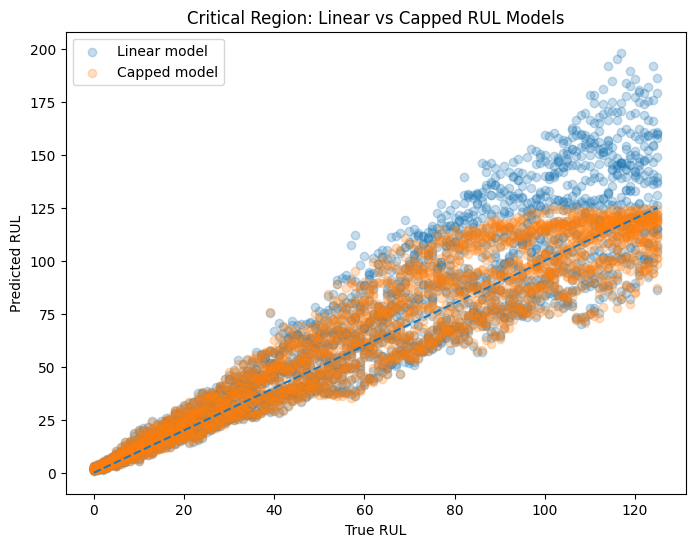

In [35]:
plt.figure(figsize=(8, 6))

plt.scatter(
    critical_true_rul,
    linear_critical_predictions,
    alpha=0.25,
    label="Linear model",
)

plt.scatter(
    critical_true_rul,
    capped_critical_predictions,
    alpha=0.25,
    label="Capped model",
)

plt.plot(
    [0, RUL_CAP],
    [0, RUL_CAP],
    linestyle="--",
)

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title(
    "Critical Region: "
    "Linear vs Capped RUL Models"
)
plt.legend()
plt.show()

In [36]:
critical_mae_improvement = (
    (
        linear_critical_mae
        - capped_critical_mae
    )
    / linear_critical_mae
    * 100
)

critical_rmse_improvement = (
    (
        linear_critical_rmse
        - capped_critical_rmse
    )
    / linear_critical_rmse
    * 100
)

print(
    f"Capped-model MAE improvement "
    f"in critical region: "
    f"{critical_mae_improvement:.2f}%"
)

print(
    f"Capped-model RMSE improvement "
    f"in critical region: "
    f"{critical_rmse_improvement:.2f}%"
)

Capped-model MAE improvement in critical region: 32.11%
Capped-model RMSE improvement in critical region: 35.92%


## Final-Target Window Consistency Check

The initial temporal-window ablation used the linear RUL target.

Because the finalized project later adopted a capped RUL target, the
same window candidates are evaluated again using the final target
definition.

The following components remain fixed:

- selected sensor set,
- Random Forest architecture,
- model hyperparameters,
- engine-level train-validation split,
- random state,
- and evaluation metrics.

Only the rolling window and EMA span change.

In [37]:
final_target_df = load_cmapss_data(
    train_path
)

final_target_df = add_train_rul(
    final_target_df,
    rul_cap=RUL_CAP,
)

final_target_window_results = []

for window in window_candidates:
    experiment_start = time.perf_counter()

    experiment_df = add_sensor_history_features(
        final_target_df,
        sensors=selected_sensors,
        rolling_window=window,
        ema_span=window,
    ).reset_index(drop=True)

    feature_columns = build_feature_columns(
        sensors=selected_sensors,
        rolling_window=window,
        ema_span=window,
    )

    train_df = experiment_df[
        experiment_df["id"].isin(
            train_engine_ids
        )
    ].reset_index(drop=True)

    validation_df = experiment_df[
        experiment_df["id"].isin(
            validation_engine_ids
        )
    ].reset_index(drop=True)

    X_train = train_df[feature_columns]
    y_train = train_df["RUL"]

    X_validation = validation_df[
        feature_columns
    ]
    y_validation = validation_df["RUL"]

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(
        X_train,
        y_train,
    )

    predictions = model.predict(
        X_validation
    )

    mae = mean_absolute_error(
        y_validation,
        predictions,
    )

    rmse = root_mean_squared_error(
        y_validation,
        predictions,
    )

    r2 = r2_score(
        y_validation,
        predictions,
    )

    elapsed_seconds = (
        time.perf_counter()
        - experiment_start
    )

    final_target_window_results.append(
        {
            "window": window,
            "ema_span": window,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "elapsed_seconds": elapsed_seconds,
        }
    )

    print(
        f"Window {window}: "
        f"MAE={mae:.3f}, "
        f"RMSE={rmse:.3f}, "
        f"R²={r2:.3f}, "
        f"time={elapsed_seconds:.1f}s"
    )

Window 3: MAE=9.132, RMSE=12.607, R²=0.909, time=2.7s
Window 5: MAE=8.755, RMSE=12.124, R²=0.916, time=2.7s
Window 10: MAE=8.415, RMSE=11.575, R²=0.923, time=2.7s
Window 20: MAE=8.721, RMSE=11.851, R²=0.919, time=3.1s


In [38]:
final_target_window_results_df = (
    pd.DataFrame(
        final_target_window_results
    )
    .sort_values("MAE")
    .reset_index(drop=True)
)

final_target_window_results_df

,window,ema_span,MAE,RMSE,R2,elapsed_seconds
0,10,10,8.415468,11.574838,0.923010,2.701107
1,20,20,8.720507,11.851343,0.919288,3.116809
2,5,5,8.755368,12.124018,0.915531,2.709340
3,3,3,9.131989,12.607494,0.908660,2.711719


In [39]:
assert len(
    final_target_window_results_df
) == len(window_candidates)

assert set(
    final_target_window_results_df[
        "window"
    ]
) == set(window_candidates)

assert (
    final_target_window_results_df[
        ["MAE", "RMSE", "R2"]
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

final_target_best_row = (
    final_target_window_results_df
    .iloc[0]
)

final_target_best_window = int(
    final_target_best_row["window"]
)

assert final_target_best_window == 10

print(
    "Best final-target window:",
    final_target_best_window,
)

print(
    "Best final-target MAE:",
    f"{final_target_best_row['MAE']:.3f}",
)

print(
    "Best final-target RMSE:",
    f"{final_target_best_row['RMSE']:.3f}",
)

print(
    "Best final-target R²:",
    f"{final_target_best_row['R2']:.3f}",
)

print(
    "Final-target window consistency "
    "check passed."
)

Best final-target window: 10
Best final-target MAE: 8.415
Best final-target RMSE: 11.575
Best final-target R²: 0.923
Final-target window consistency check passed.


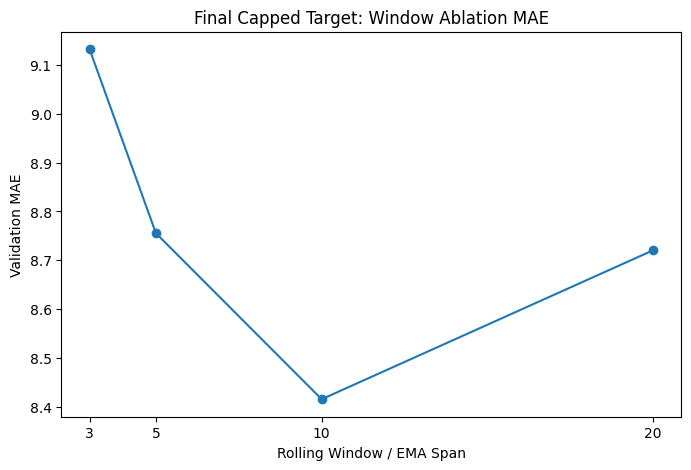

In [40]:
final_target_plot_data = (
    final_target_window_results_df
    .sort_values("window")
)

plt.figure(figsize=(8, 5))

plt.plot(
    final_target_plot_data["window"],
    final_target_plot_data["MAE"],
    marker="o",
)

plt.xlabel("Rolling Window / EMA Span")
plt.ylabel("Validation MAE")
plt.title(
    "Final Capped Target: "
    "Window Ablation MAE"
)
plt.xticks(window_candidates)
plt.show()

## Final-Target Window Consistency Results

The temporal-window candidates were evaluated again using the finalized
capped RUL target.

| Window / EMA Span | MAE | RMSE | R² |
|---:|---:|---:|---:|
| 3 | 9.132 | 12.607 | 0.909 |
| 5 | 8.755 | 12.124 | 0.916 |
| 10 | 8.415 | 11.575 | 0.923 |
| 20 | 8.721 | 11.851 | 0.919 |

The 10-cycle configuration remained the strongest option across MAE,
RMSE, and R².

This consistency check confirms that the final temporal configuration
is not dependent only on the original linear-target experiment.

# Notebook Summary

This notebook evaluated two major modeling-design decisions.

First, temporal windows of 3, 5, 10, and 20 cycles were compared under
a fixed engine-level validation protocol.

A 10-cycle rolling window and EMA span achieved the strongest
validation performance. A follow-up evaluation using the finalized
capped target confirmed the same ranking.

Second, linear and capped RUL targets were compared.

The capped target substantially improved prediction performance in the
shared critical region where both target definitions represent the same
ground truth.

The finalized modeling configuration is therefore:

- capped RUL with a maximum value of 125 cycles,
- 10-cycle rolling mean,
- 10-cycle EMA span,
- leakage-safe historical features,
- and engine-level validation.

These decisions are treated as empirically supported project
configurations rather than universal physical constants.